# Exploration du BOAMP

Deuxième source du projet. Le **BOAMP**, Bulletin officiel des annonces des marchés publics, est
édité par la DILA, la Direction de l'information légale et administrative, qui dépend des services
du Premier ministre. Il publie les avis **avant** et **après** la passation d'un marché, là où les
DECP ne décrivent que les marchés déjà attribués.

C'est une différence de nature, pas de volume : les DECP racontent le passé, le BOAMP annonce ce qui
est ouvert maintenant. Pour une PME qui cherche un marché auquel répondre, c'est la seule des deux
sources qui serve à quelque chose.

**Accès** : API Opendatasoft, sans clé, sous Licence Ouverte 2.0.

## Comment on interroge l'API, et avec quoi

L'API accepte une requête par URL et répond en JSON. Trois façons de l'appeler depuis Python :

| Option | Avantage | Limite | Choix ici |
|---|---|---|---|
| `urllib`, bibliothèque standard | zéro dépendance, disponible partout | pas de reprise sur erreur, code un peu verbeux | **retenu pour l'exploration** |
| `requests` | la plus connue, API agréable | synchrone uniquement, projet en maintenance douce | non |
| `httpx` | même API que `requests`, plus l'asynchrone et les délais d'attente fins | une dépendance de plus | retenu **en phase 3**, quand la collecte devra être robuste |

Le principe est le même que pour le reste du projet : on ne prend une dépendance que lorsque le
besoin est démontré. Ici, quelques appels en lecture suffisent, la bibliothèque standard fait le
travail. En phase 3, la collecte devra réessayer, limiter son débit et journaliser ses erreurs, et
là `httpx` se justifiera.

In [1]:
import json
import sys
import urllib.parse
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("..")

from mesures.figures import ENCRE, FILET, GRIS, SERIE_1, SERIE_2, legender, soigner  # noqa: E402

%matplotlib inline

API = "https://boamp-datadila.opendatasoft.com/api/explore/v2.1/catalog/datasets/boamp/records"


def interroger(**parametres: object) -> dict:
    """Appelle l'API et renvoie la réponse JSON.

    En-tête `Accept-Encoding: identity` : sans lui, le serveur renvoie du gzip que `urllib` ne
    décompresse pas tout seul, contrairement à `requests` ou `httpx`. C'est exactement le genre de
    détail qu'une bibliothèque tierce prend en charge, et l'une des raisons de passer à `httpx`
    quand la collecte deviendra sérieuse.
    """
    url = f"{API}?{urllib.parse.urlencode(parametres)}"
    requete = urllib.request.Request(  # noqa: S310
        url, headers={"Accept-Encoding": "identity"}
    )
    # noqa S310 : l'analyseur signale tout appel a urlopen, car une URL peut pointer vers un
    # fichier local. Ici l'adresse est construite a partir d'une constante du notebook.
    with urllib.request.urlopen(requete, timeout=60) as reponse:  # noqa: S310
        return json.loads(reponse.read())


bornes = interroger(
    select="max(dateparution) as recent, min(dateparution) as ancien, count(*) as avis"
)
bornes["results"][0]

{'recent': '2026-09-21T00:00:00+00:00',
 'ancien': '2015-03-02T00:00:00+00:00',
 'avis': 1708108}

## 1. Une métadonnée qui ment

Le catalogue annonce une dernière modification au **25 août 2025**, soit il y a plus d'un an. De quoi
croire le jeu abandonné et passer à autre chose.

La mesure ci-dessus dit l'inverse : l'avis le plus récent date **d'aujourd'hui**, le plus ancien du
2 mars 2015, pour environ 1,708 million d'avis.

**Leçon de méthode, à écrire dans le mémoire** : une métadonnée décrit une intention, la donnée
décrit un fait. On vérifie la fraîcheur d'une source en regardant la donnée, jamais sa fiche.

## 2. Volumétrie, année par année

L'API sait grouper, mais elle refuse de renvoyer l'alias d'une expression de date dans un
groupement. Plutôt que de contourner par une astuce fragile, on pose douze questions simples : une
par année. Douze appels d'une milliseconde chacun valent mieux qu'une requête illisible.

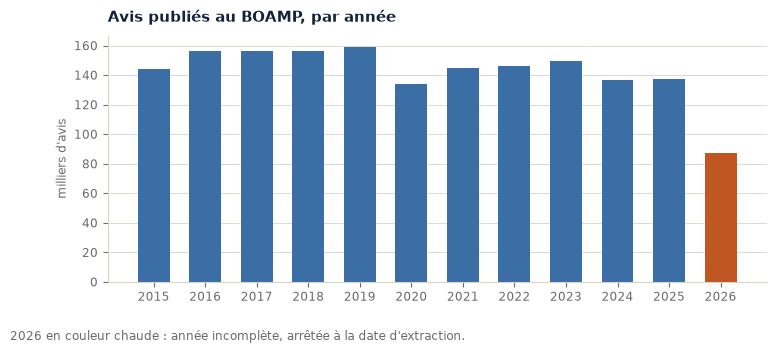

,annee,avis
0,2015,144480
1,2016,156034
2,2017,156366
3,2018,156060
4,2019,158839
5,2020,134138
6,2021,145161
7,2022,146286
8,2023,149300
9,2024,136625


In [2]:
volumes = pd.DataFrame(
    {
        "annee": annee,
        "avis": interroger(
            select="count(*) as avis",
            where=f"dateparution >= date'{annee}-01-01' and dateparution < date'{annee + 1}-01-01'",
        )["results"][0]["avis"],
    }
    for annee in range(2015, 2027)
)

figure, axes = plt.subplots(figsize=(8.5, 3.2))
# 2026 est incomplète : on la distingue au lieu de laisser croire à un effondrement.
couleurs = [SERIE_2 if a == 2026 else SERIE_1 for a in volumes["annee"]]
axes.bar(volumes["annee"].astype(str), volumes["avis"] / 1000, color=couleurs, width=0.62)
axes.set_ylabel("milliers d'avis", color=GRIS, fontsize=8.5)
soigner(axes, "Avis publiés au BOAMP, par année")
legender(figure, "2026 en couleur chaude : année incomplète, arrêtée à la date d'extraction.")
plt.show()

volumes

**Ce qu'on y lit** : environ 145 000 avis par an, remarquablement stable depuis 2016. Pas de rupture,
pas de dérive : contrairement aux DECP consolidées, dont la hausse apparente vient en partie de
l'élargissement de la collecte, le BOAMP est une source unique et homogène depuis dix ans.

**Ce que ça change** : pour toute analyse d'évolution dans le temps, le BOAMP est une base plus sûre
que les DECP.

## 3. Que contient un avis, et de quel type

Un avis n'est pas un marché. Le même marché donne lieu à plusieurs avis : l'appel d'offres, parfois
un rectificatif, puis le résultat. C'est une unité de comptage de plus, à ne pas confondre avec les
trois déjà rencontrées côté DECP.

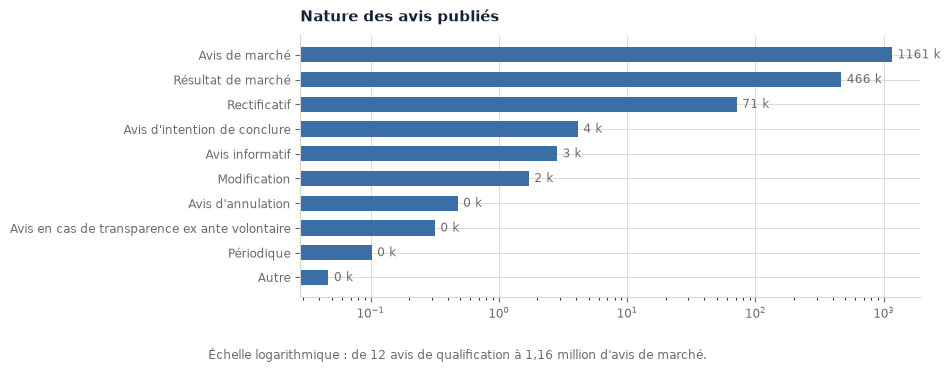

In [3]:
natures = pd.DataFrame(
    interroger(
        select="nature_libelle, count(*) as avis",
        group_by="nature_libelle",
        order_by="avis desc",
        limit=10,
    )["results"]
).dropna()

figure, axes = plt.subplots(figsize=(8, 3.4))
barres = axes.barh(natures["nature_libelle"], natures["avis"] / 1000, color=SERIE_1, height=0.62)
axes.bar_label(barres, fmt="%.0f k", padding=4, color=GRIS, fontsize=8.5)
axes.invert_yaxis()
axes.set_xscale("log")
axes.grid(axis="y", visible=False)
axes.grid(axis="x", color=FILET, linewidth=0.6)
soigner(axes, "Nature des avis publiés")
legender(
    figure,
    "Échelle logarithmique : de 12 avis de qualification à 1,16 million d'avis de marché.",
)
plt.show()

**Ce qu'on y lit** : 1 160 935 avis de marché, c'est-à-dire des appels à candidature, et
465 999 résultats de marché, c'est-à-dire des attributions. Le reste est marginal.

L'échelle logarithmique est ici une nécessité, pas une coquetterie : sans elle, les catégories à
quelques centaines d'avis seraient invisibles à côté du million.

**Ce que ça change** : les résultats de marché sont le pont vers les DECP, puisqu'ils portent sur
des marchés attribués. Les avis de marché, eux, sont la matière du service rendu à la PME.

## 4. Le produit : ce qui est ouvert maintenant

C'est la question que pose une PME, et à laquelle les DECP ne peuvent pas répondre.

In [4]:
ouverts = interroger(select="count(*) as avis", where="datelimitereponse > now()")["results"][0]
print(f"{ouverts['avis']:,} appels d'offres sont ouverts à cet instant".replace(",", " "))

procedures = pd.DataFrame(
    interroger(
        select="procedure_libelle, count(*) as avis",
        where="datelimitereponse > now()",
        group_by="procedure_libelle",
        order_by="avis desc",
        limit=10,
    )["results"]
).dropna()
procedures

7 800 appels d'offres sont ouverts à cet instant


,procedure_libelle,avis
0,Procédure Ouverte,6903
1,Procédure Adaptée,516
2,Procédure Restreinte,181
3,Procédure NC,151
4,Procédure Négociée,41
5,Procédure Dialogue compétitif,7
6,Procédure Partenariat innovation,1


**Ce qu'on y lit** : environ huit mille appels d'offres ouverts à l'instant où ce notebook s'exécute,
dont une écrasante majorité en procédure ouverte, celle où n'importe quelle entreprise peut déposer
une offre sans sélection préalable.

**Ce que ça change** : c'est la fonction centrale du service. Un moteur de recherche sur huit mille
avis ouverts, filtrés par métier et par territoire, a une valeur immédiate pour une PME. Aucune
modélisation n'est nécessaire pour cela : une recherche textuelle et deux filtres suffisent. Encore
le principe de l'escalier.

## 5. Combien de temps a-t-on pour répondre

L'API sait compter et grouper, mais elle ne sait pas calculer une différence entre deux dates :
elle refuse `date_diff`. Deux options : contourner en SQL côté serveur, ou rapatrier un échantillon
et calculer localement.

On rapatrie. La règle est simple : **agréger côté serveur quand on le peut, calculer localement
quand le serveur ne sait pas faire.** Ici, mille avis suffisent à estimer une distribution.

997 avis, délai médian : 31 jours


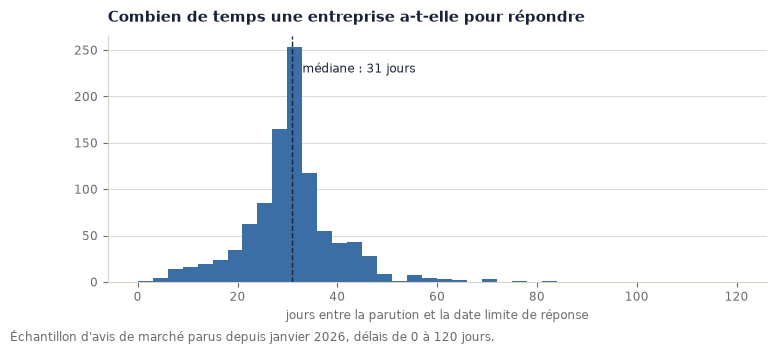

In [5]:
recents = pd.DataFrame(
    interroger(
        select="dateparution, datelimitereponse, procedure_libelle",
        where="nature_libelle='Avis de marché' and datelimitereponse is not null"
        " and dateparution > date'2026-01-01'",
        order_by="dateparution desc",
        limit=100,
    )["results"]
)
for page in range(1, 10):
    recents = pd.concat(
        [
            recents,
            pd.DataFrame(
                interroger(
                    select="dateparution, datelimitereponse, procedure_libelle",
                    where="nature_libelle='Avis de marché' and datelimitereponse is not null"
                    " and dateparution > date'2026-01-01'",
                    order_by="dateparution desc",
                    limit=100,
                    offset=page * 100,
                )["results"]
            ),
        ]
    )

recents["parution"] = pd.to_datetime(recents["dateparution"], utc=True)
recents["limite"] = pd.to_datetime(recents["datelimitereponse"], utc=True)
recents["delai"] = (recents["limite"] - recents["parution"]).dt.days
delais = recents[recents["delai"].between(0, 120)]

print(f"{len(delais)} avis, délai médian : {delais['delai'].median():.0f} jours")

figure, axes = plt.subplots(figsize=(8.5, 3.2))
axes.hist(delais["delai"], bins=range(0, 122, 3), color=SERIE_1)
axes.axvline(delais["delai"].median(), color=ENCRE, linewidth=1, linestyle="--")
axes.text(
    delais["delai"].median() + 2,
    axes.get_ylim()[1] * 0.85,
    f"médiane : {delais['delai'].median():.0f} jours",
    color=ENCRE,
    fontsize=8.5,
)
axes.set_xlabel("jours entre la parution et la date limite de réponse", color=GRIS, fontsize=8.5)
soigner(axes, "Combien de temps une entreprise a-t-elle pour répondre")
legender(figure, "Échantillon d'avis de marché parus depuis janvier 2026, délais de 0 à 120 jours.")
plt.show()

**Ce qu'on y lit** : une médiane autour d'un mois, avec une concentration marquée sur quelques
valeurs rondes, les délais réglementaires minimaux.

**Ce que ça change** : le service devra afficher le temps restant, pas seulement la date. Et la
fraîcheur de la collecte devient une exigence : avec un délai médian d'un mois, une collecte
hebdomadaire ferait perdre un quart du temps utile à l'entreprise. Ce sera un argument pour la
fréquence d'exécution des pipelines en phase 3.

## 6. Peut-on relier le BOAMP aux DECP ?

Question structurante pour toute la suite : si les deux sources se rejoignaient par un identifiant
commun, on obtiendrait la chaîne complète, de l'appel d'offres jusqu'au montant attribué.

Le BOAMP expose un champ `contractfolderid`. On le confronte aux identifiants des DECP.

In [6]:
identifiants = []
for page in range(6):
    reponse = interroger(
        select="contractfolderid",
        where="contractfolderid is not null",
        order_by="dateparution desc",
        limit=100,
        offset=page * 100,
    )
    identifiants += [r["contractfolderid"] for r in reponse["results"] if r["contractfolderid"]]

print(f"{len(identifiants)} identifiants côté BOAMP, par exemple :")
for exemple in identifiants[:3]:
    print("  ", exemple)

600 identifiants côté BOAMP, par exemple :
   e46c0e23-481f-4aef-8446-59e4999637cb
   5c48b601-8112-4597-a690-3cdeaf1735db
   b0035d8f-31cf-4cde-8868-5603bdd58cf4


In [7]:
import duckdb  # noqa: E402

con = duckdb.connect()
con.register("decp", con.read_parquet("../donnees/brut/decp.parquet"))
con.execute("create table cles (cle varchar)")
con.executemany("insert into cles values (?)", [(i,) for i in identifiants])

print("identifiants DECP, pour comparaison :")
print(con.sql("select uid, id from decp limit 3").df().to_string(index=False))
print()
# Le nom de colonne vient d'un tuple ecrit juste au-dessus, pas d'une saisie exterieure. L'alerte
# d'injection SQL de l'analyseur est donc un faux positif, signale comme tel plutot qu'ignore.
for colonne in ("id", "uid"):
    requete = f"select count(*) from cles c join decp d on d.{colonne} = c.cle"  # noqa: S608
    n = con.sql(requete).fetchone()[0]
    print(f"correspondances exactes sur decp.{colonne} : {n}")
n = con.sql("select count(*) from cles c join decp d on contains(d.uid, c.cle)").fetchone()[0]
print(f"identifiant BOAMP contenu dans decp.uid : {n}")

identifiants DECP, pour comparaison :
                              uid         id
19860856400375202623609S_55520000 202623609S
19860856400375202623610S_55520000 202623610S
19860856400375202623619S_55520000 202623619S



correspondances exactes sur decp.id : 0


correspondances exactes sur decp.uid : 0


identifiant BOAMP contenu dans decp.uid : 0


**Résultat : aucune correspondance, sur 600 avis récents.**

L'explication tient à la façon dont chaque identifiant est fabriqué. Le BOAMP porte un identifiant
technique produit par la plateforme de dématérialisation de l'acheteur, sous forme d'UUID. Les DECP
portent un identifiant choisi par l'acheteur lui-même, souvent un numéro de dossier interne, combiné
à son SIRET. Les deux décrivent le même marché, sans jamais se rencontrer.

**Ce que ça change, et c'est important** : relier les deux sources ne sera pas une jointure, ce sera
un **rapprochement d'enregistrements**. Il faudra comparer l'acheteur, l'objet du marché et les
dates, avec une part d'incertitude à mesurer et à assumer. C'est un chantier à part entière, qui
mérite son propre ADR et sa propre section dans le mémoire.

C'est aussi, à nouveau, le principe de l'escalier : jointure exacte d'abord, puisqu'elle est
gratuite ; elle échoue, donc on monte d'une marche vers des règles sur le SIRET et les dates ; et
seulement si la mesure le justifie, vers un rapprochement flou puis une comparaison sémantique des
objets de marché.

In [8]:
# La piste : le champ détaillé contient le SIRET de l'acheteur, absent des colonnes de premier
# niveau. C'est lui qui servira de point d'ancrage au rapprochement.
detail = interroger(
    select="donnees",
    where="nature_libelle='Résultat de marché'",
    order_by="dateparution desc",
    limit=1,
)["results"][0]["donnees"]

contenu = json.loads(detail) if isinstance(detail, str) else detail
organisme = contenu.get("FNSimple", {}).get("organisme", {})
print("acheteur  :", organisme.get("nomOfficiel"))
print("SIRET     :", organisme.get("codeIdentificationNational"))
print("ville     :", organisme.get("ville"), organisme.get("cp"))

acheteur  : Commune de Tarascon
SIRET     : 21130108000019
ville     : Tarascon cedex 13158


Le SIRET de l'acheteur est bien là, dans le champ détaillé. Comme les DECP portent elles aussi le
SIRET de l'acheteur, le rapprochement a une clé solide pour commencer : **même acheteur, dates
proches, objets similaires**.

Reste à mesurer combien de marchés cette approche retrouve réellement. Ce sera l'objet d'une mesure
dédiée en phase 3, et le taux obtenu sera publié, y compris s'il est décevant.

## Ce que le BOAMP apporte, et ce qu'il n'apporte pas

| | DECP consolidées | BOAMP |
|---|---|---|
| Ce que ça décrit | des marchés **attribués** | des avis **avant** et **après** la passation |
| Volume | 1,83 million de marchés | 1,71 million d'avis |
| Période | 2018 à 2026 | 2015 à 2026 |
| Montant attribué | oui, dans 98,5 % des cas | rarement, et en texte libre |
| Date limite de réponse | non | **oui**, c'est sa raison d'être |
| Marchés ouverts en ce moment | impossible par construction | **environ 8 000** |
| Homogénéité de la source | 63 sources agrégées | une seule source depuis dix ans |
| Identifiant commun avec l'autre source | non | non |

**Conclusion pour l'architecture** : les deux sources ne se remplacent pas, elles se complètent, et
elles ne se joignent pas. Le service rendu à la PME repose sur le BOAMP, l'analyse des prix et des
risques repose sur les DECP, et le rapprochement des deux est un chantier de recherche à mesurer,
pas une jointure à écrire.

**Prochaine étape** : l'API Recherche d'entreprises, troisième source, qui permettra d'enrichir les
22 % de marchés sans catégorie d'acheteur et de donner un nom lisible aux SIRET des deux côtés.